### Emmaus

# Check if the bounding boxes are correct

I will check probably just LIDC-IDRI-0001 for verification that the bounding boxes were done correctly. I am pretty sure it was done correctly based on the info from check_patches.ipynb but whatever because I should probably get pictures to show people that my process works

LIDC-IDRI-0001: 1 nodule(s), 9 slices with a box
box SOP UID matches the slice found by z: 9 of 9


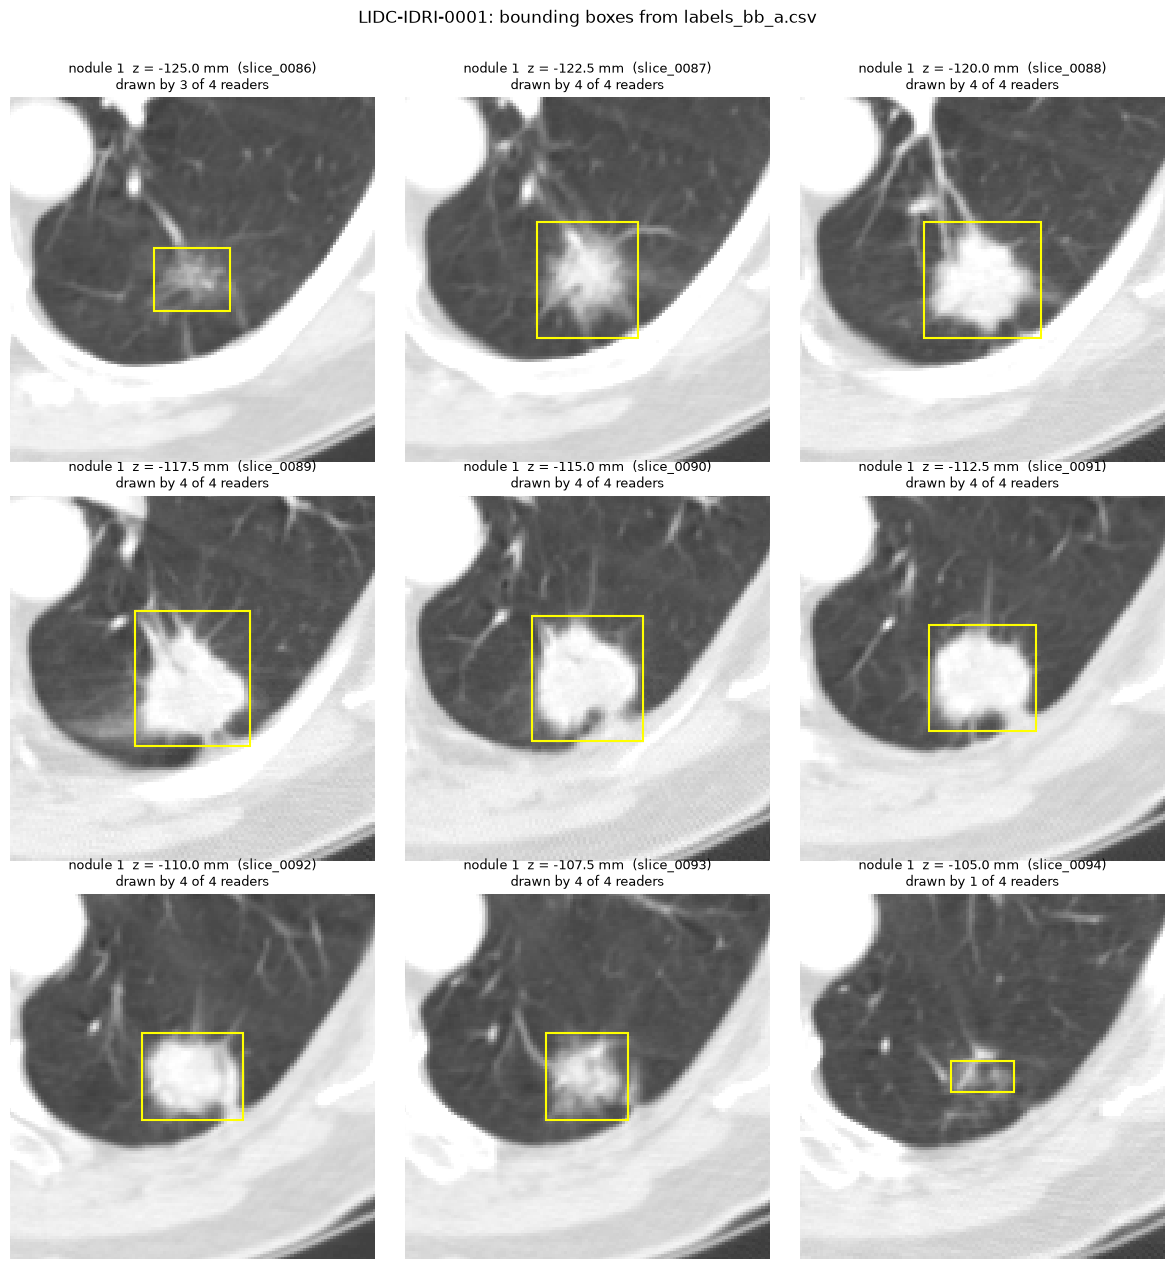

In [ ]:
import sys
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle

sys.path.insert(0, str(Path.cwd().parent / "pipeline"))
from ct import BOXES, load_slice_index, read_hu, slice_path, to_uint8_window

PATIENT = "LIDC-IDRI-0001"
ZOOM_WIDTH_PX = 120 # If you put None it will just show the whole 512x512 slice
Z_MATCH_MM = 0.1 # A box's z must be this close to a real slice

boxes = pd.read_csv(BOXES)
# "z-slice" renamed to "z_slice"
boxes = (boxes[boxes["patient_id"] == PATIENT].rename(columns={"z-slice": "z_slice"})
         .sort_values(["merged_nodule_id", "z_slice"]).reset_index(drop=True))
slices = load_slice_index()

# Find each box's DICOM file by z position, similar to pipeline
slice_matches = []
for box in boxes.itertuples():
    series_slices = slices[slices["series_instance_uid"] == box.series_instance_uid]
    # Note that slice_index.csv uses "z" while labels_bb_a.csv uses "z-slice"
    nearest = series_slices.iloc[(series_slices["z"] - box.z_slice).abs().argmin()]
    z_err = abs(nearest["z"] - box.z_slice)
    assert z_err <= Z_MATCH_MM, f"box at z={box.z_slice} has no slice within {Z_MATCH_MM} mm"
    slice_matches.append({"idx": int(nearest["idx"]), "sop_matches": nearest["sop"] == box.image_sop_id})
boxes = boxes.join(pd.DataFrame(slice_matches))

print(f"{PATIENT}: {boxes['merged_nodule_id'].nunique()} nodule(s), {len(boxes)} slices with a box")
print(f"box SOP UID matches the slice found by z: {boxes['sop_matches'].sum()} of {len(boxes)}")

cols = 3
rows = ceil(len(boxes) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4.3 * rows))
axes = axes.ravel()

for ax, box in zip(axes, boxes.itertuples()):
    hu = read_hu(slice_path(box.patient_id, box.series_instance_uid, box.idx))
    # Fixed lung window, as in the YOLO images. vmin/vmax stop matplotlib from
    # stretching each slice to its own darkest and brightest pixel
    ax.imshow(to_uint8_window(hu), cmap="gray", vmin=0, vmax=255)

    # Bounding box outline needs to be aligned with the pixels 
    left = box.x_centre - box.width / 2 - 0.5
    top = box.y_centre - box.height / 2 - 0.5
    ax.add_patch(Rectangle((left, top), box.width + 1, box.height + 1,
                           edgecolor="yellow", facecolor="none", linewidth=1.5))

    if ZOOM_WIDTH_PX is not None:
        half = ZOOM_WIDTH_PX / 2
        ax.set_xlim(box.x_centre - half, box.x_centre + half)
        ax.set_ylim(box.y_centre + half, box.y_centre - half) # bigger row number first: image rows count downwards, so this keeps the image upright
    ax.set_title(f"nodule {box.merged_nodule_id}  z = {box.z_slice} mm  (slice_{box.idx:04d})\n"
                 f"drawn by {box.readers_on_slice} of {box.num_readers} readers", fontsize=9)
    ax.axis("off")

for ax in axes[len(boxes):]:
    ax.axis("off") # hide empty panels in the last row
fig.suptitle(f"{PATIENT}: bounding boxes from labels_bb_a.csv", fontsize=12)
plt.tight_layout(rect=(0, 0, 1, 0.97)) # leave room for the title